# Milestone 3 – Route, Cancellation & Seasonal Insights

**AirFly Insights** | Week 5–6 Analysis

This notebook covers:
- **Week 5**: Route & airport-level analysis (top routes, delay heatmaps, Folium maps)
- **Week 6**: Seasonal & cancellation analysis (monthly trends, cancellation types, holiday impact)

---

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load Data ────────────────────────────────────────────────────────
dtype_spec = {
    'YEAR': 'int16', 'MONTH': 'int8', 'DAY': 'int8', 'DAY_OF_WEEK': 'int8',
    'AIRLINE': 'category', 'FLIGHT_NUMBER': 'int32',
    'ORIGIN_AIRPORT': 'str', 'DESTINATION_AIRPORT': 'str',
    'DISTANCE': 'float32',
    'SCHEDULED_DEPARTURE': 'float32', 'DEPARTURE_TIME': 'float32',
    'SCHEDULED_ARRIVAL': 'float32', 'ARRIVAL_TIME': 'float32',
    'DEPARTURE_DELAY': 'float32', 'ARRIVAL_DELAY': 'float32',
    'AIR_SYSTEM_DELAY': 'float32', 'WEATHER_DELAY': 'float32',
    'AIRLINE_DELAY': 'float32', 'SECURITY_DELAY': 'float32',
    'LATE_AIRCRAFT_DELAY': 'float32',
    'CANCELLED': 'int8', 'CANCELLATION_REASON': 'category', 'DIVERTED': 'int8',
    'AIR_TIME': 'float32', 'ELAPSED_TIME': 'float32',
    'TAXI_IN': 'float32', 'TAXI_OUT': 'float32',
    'HOUR': 'int8', 'ROUTE': 'str'
}

df = pd.read_csv('../data/cleaned_flights.csv', dtype=dtype_spec, parse_dates=['DATE'])
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset loaded: 5,819,079 rows × 30 columns


Memory usage: 1575.0 MB


---
## Part 1 – Week 5: Route & Airport-Level Analysis

### 1. Top 10 Origin–Destination Pairs

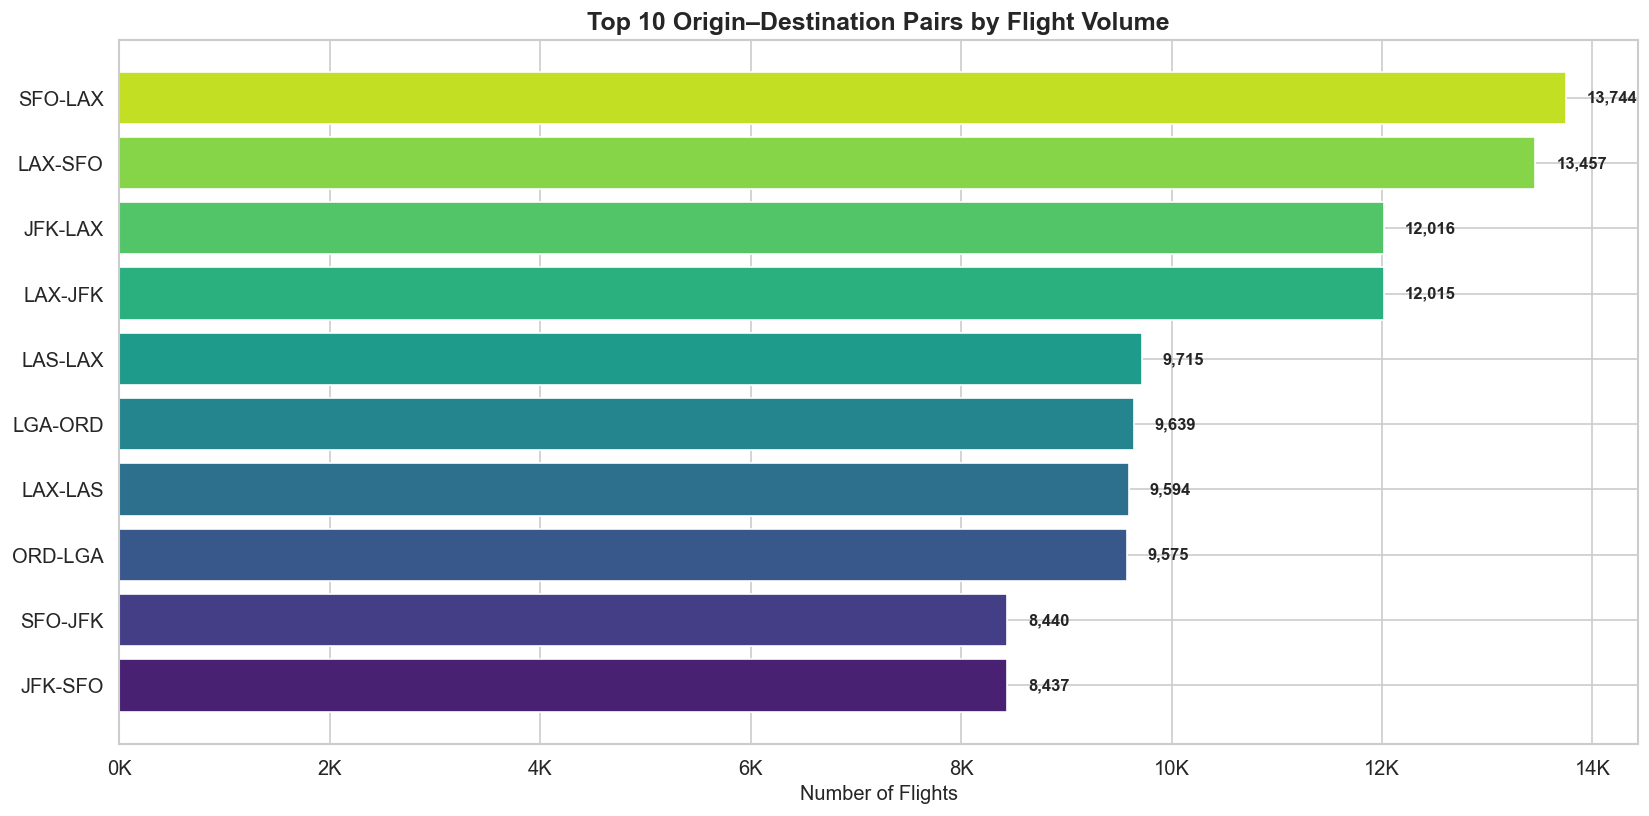


Top 10 Routes:
  Route  FlightCount
SFO-LAX        13744
LAX-SFO        13457
JFK-LAX        12016
LAX-JFK        12015
LAS-LAX         9715
LGA-ORD         9639
LAX-LAS         9594
ORD-LGA         9575
SFO-JFK         8440
JFK-SFO         8437


In [3]:
# ── Top 10 Routes by Flight Count ────────────────────────────────────
top_routes = df['ROUTE'].value_counts().head(10).reset_index()
top_routes.columns = ['Route', 'FlightCount']

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('viridis', n_colors=10)
bars = ax.barh(top_routes['Route'][::-1], top_routes['FlightCount'][::-1], color=colors)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Number of Flights', fontsize=12)
ax.set_title('Top 10 Origin–Destination Pairs by Flight Volume', fontsize=15, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print('\nTop 10 Routes:')
print(top_routes.to_string(index=False))

### 2. Delay Heatmap by Airport

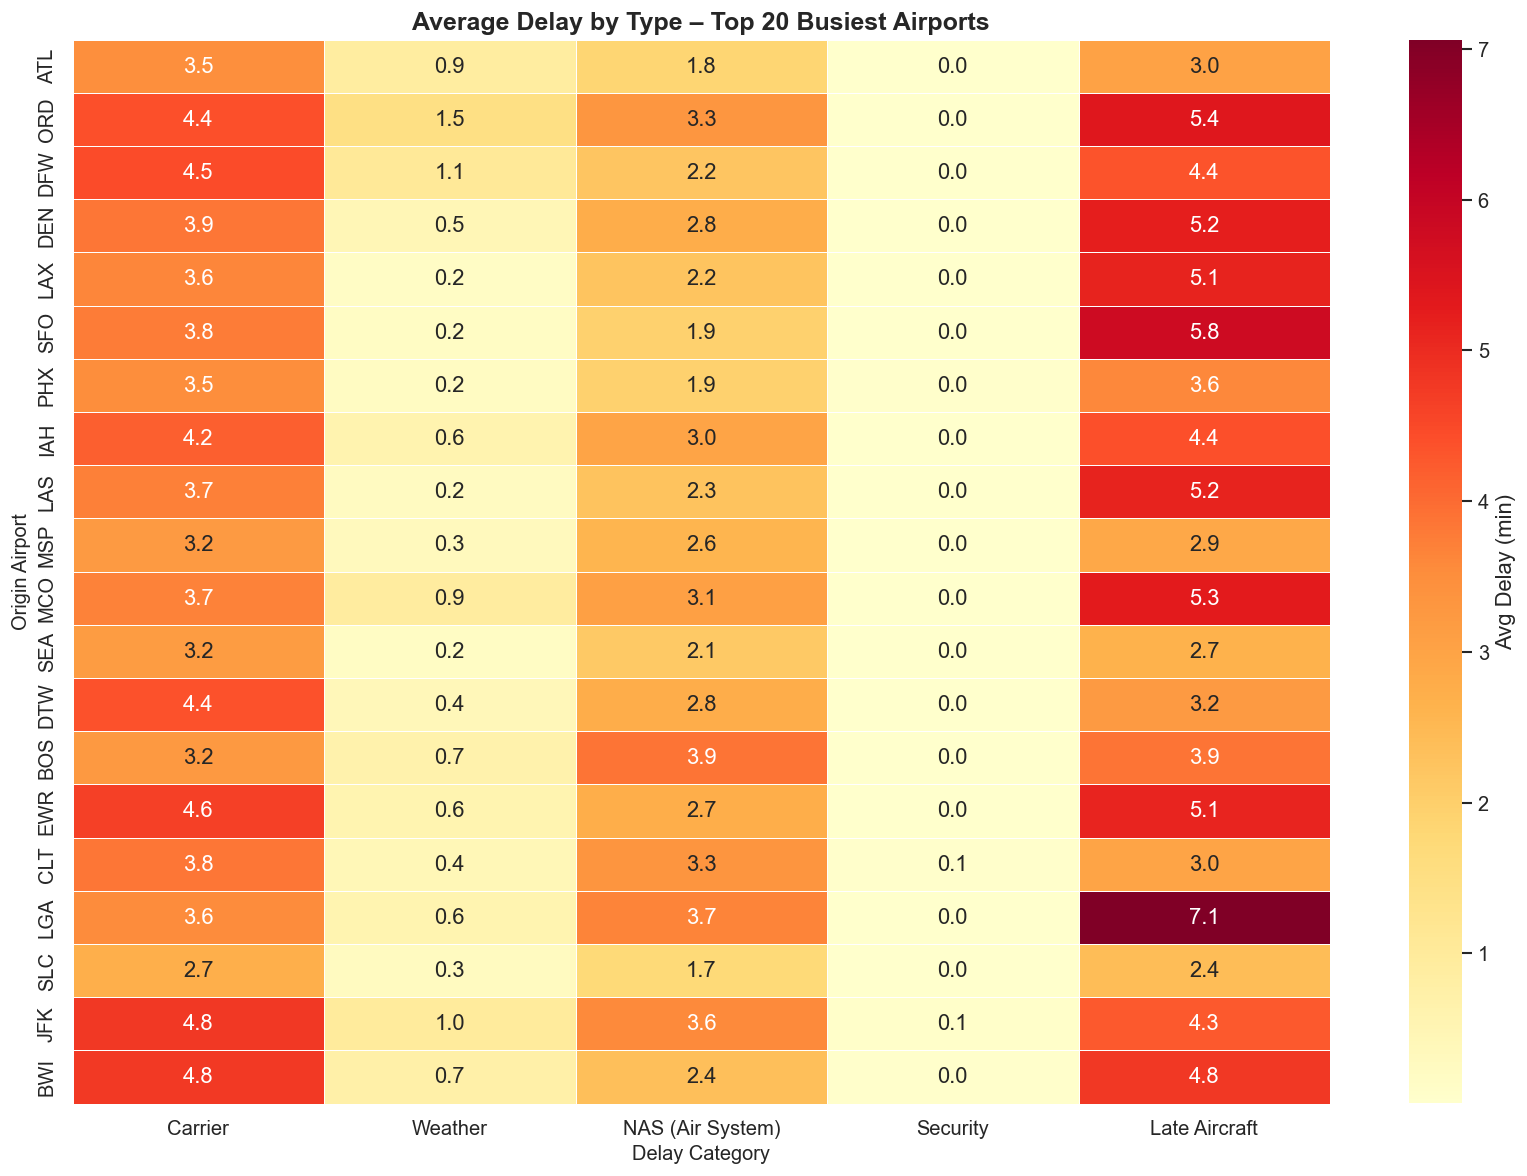

In [4]:
# ── Delay Heatmap: Top 20 Origin Airports × Delay Types ──────────────
delay_cols = ['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY',
              'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

top20_airports = df['ORIGIN_AIRPORT'].value_counts().head(20).index
airport_delays = df[df['ORIGIN_AIRPORT'].isin(top20_airports)].groupby('ORIGIN_AIRPORT')[delay_cols].mean()

# Rename columns for readability
airport_delays.columns = ['Carrier', 'Weather', 'NAS (Air System)', 'Security', 'Late Aircraft']
airport_delays = airport_delays.loc[top20_airports]  # preserve order

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(airport_delays, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Avg Delay (min)'},
            ax=ax)
ax.set_title('Average Delay by Type – Top 20 Busiest Airports', fontsize=15, fontweight='bold')
ax.set_ylabel('Origin Airport', fontsize=12)
ax.set_xlabel('Delay Category', fontsize=12)
plt.tight_layout()
plt.show()

### 3. Delay Heatmap by Route

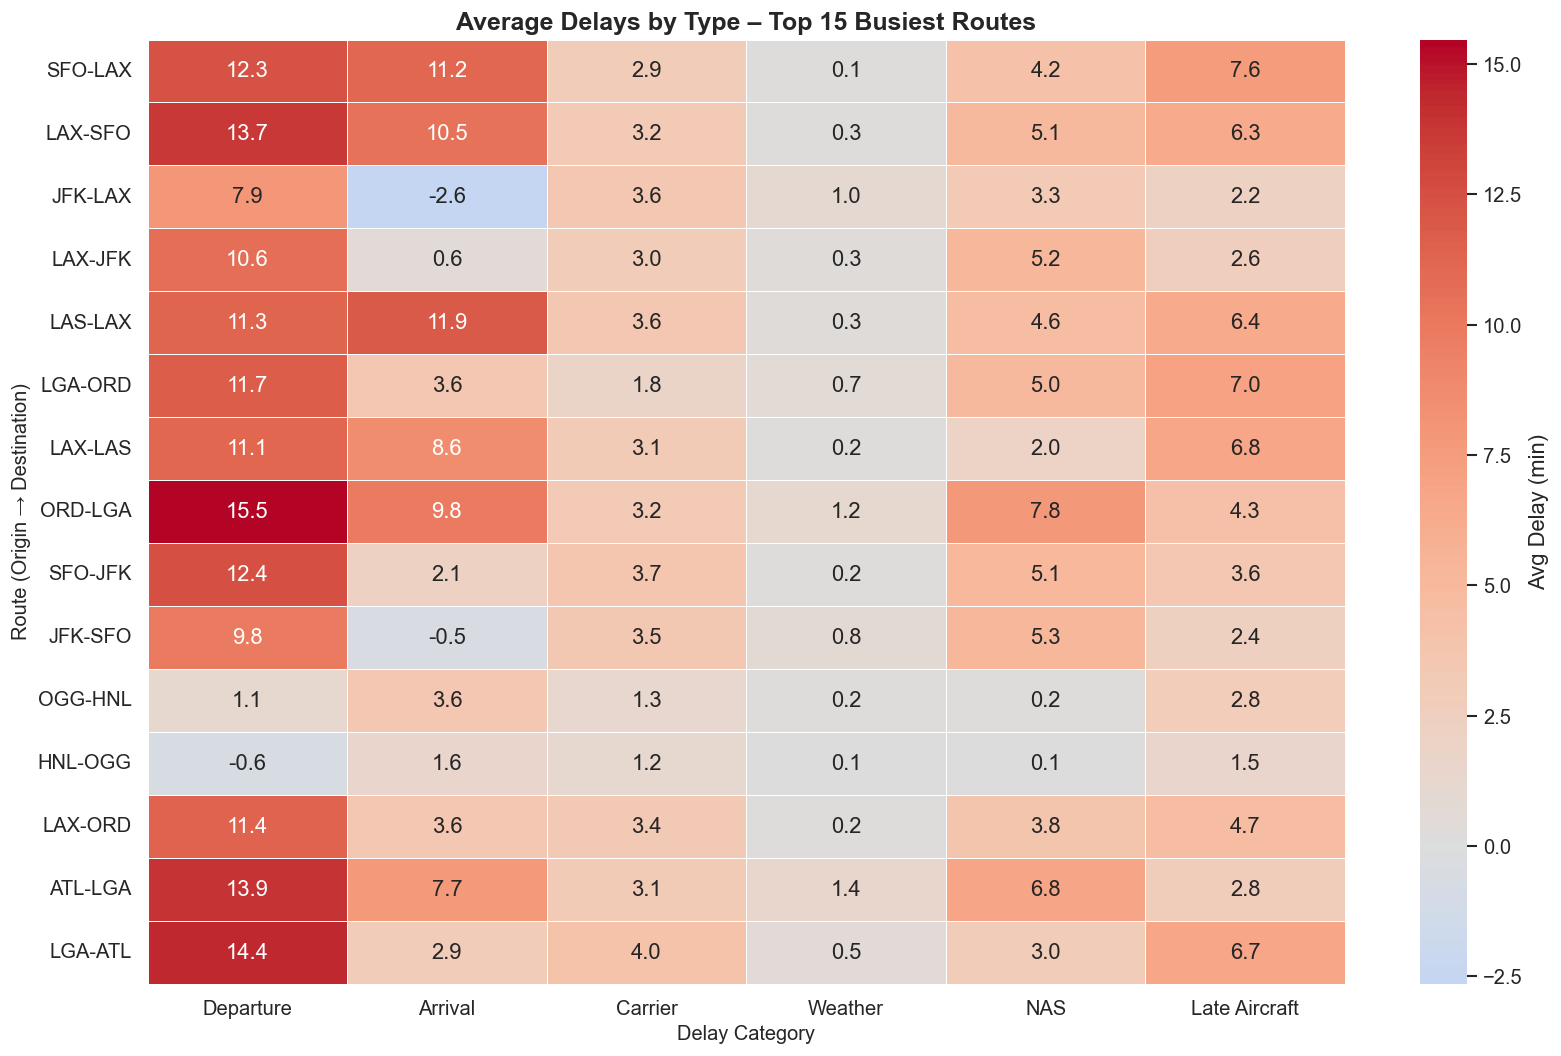

In [5]:
# ── Delay Heatmap: Top 15 Routes × Avg Delays ────────────────────────
top15_routes = df['ROUTE'].value_counts().head(15).index
route_delays = df[df['ROUTE'].isin(top15_routes)].groupby('ROUTE').agg(
    Avg_Departure_Delay=('DEPARTURE_DELAY', 'mean'),
    Avg_Arrival_Delay=('ARRIVAL_DELAY', 'mean'),
    Avg_Carrier_Delay=('AIRLINE_DELAY', 'mean'),
    Avg_Weather_Delay=('WEATHER_DELAY', 'mean'),
    Avg_NAS_Delay=('AIR_SYSTEM_DELAY', 'mean'),
    Avg_Late_Aircraft=('LATE_AIRCRAFT_DELAY', 'mean')
).loc[top15_routes]

route_delays.columns = ['Departure', 'Arrival', 'Carrier', 'Weather', 'NAS', 'Late Aircraft']

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(route_delays, annot=True, fmt='.1f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', center=0,
            cbar_kws={'label': 'Avg Delay (min)'}, ax=ax)
ax.set_title('Average Delays by Type – Top 15 Busiest Routes', fontsize=15, fontweight='bold')
ax.set_ylabel('Route (Origin → Destination)', fontsize=12)
ax.set_xlabel('Delay Category', fontsize=12)
plt.tight_layout()
plt.show()

### 4 & 5. Interactive Folium Maps

In [6]:
# ── US Airport Coordinates (Major Airports) ──────────────────────────
# Curated lat/lon for the most common US airports in the dataset
AIRPORT_COORDS = {
    'ATL': (33.6407, -84.4277), 'ORD': (41.9742, -87.9073), 'DFW': (32.8998, -97.0403),
    'DEN': (39.8561, -104.6737), 'LAX': (33.9425, -118.4081), 'SFO': (37.6213, -122.3790),
    'PHX': (33.4373, -112.0078), 'IAH': (29.9902, -95.3368), 'LAS': (36.0840, -115.1537),
    'MSP': (44.8848, -93.2223), 'DTW': (42.2124, -83.3534), 'SEA': (47.4502, -122.3088),
    'BOS': (42.3656, -71.0096), 'EWR': (40.6895, -74.1745), 'MCO': (28.4312, -81.3081),
    'JFK': (40.6413, -73.7781), 'LGA': (40.7769, -73.8740), 'CLT': (35.2140, -80.9431),
    'SLC': (40.7899, -111.9791), 'BWI': (39.1774, -76.6684), 'MDW': (41.7868, -87.7522),
    'DCA': (38.8512, -77.0402), 'FLL': (26.0742, -80.1506), 'SAN': (32.7338, -117.1933),
    'TPA': (27.9755, -82.5332), 'PDX': (45.5898, -122.5951), 'MIA': (25.7959, -80.2870),
    'HNL': (21.3187, -157.9224), 'OAK': (37.7213, -122.2208), 'AUS': (30.1975, -97.6664),
    'MSY': (29.9934, -90.2580), 'RDU': (35.8801, -78.7880), 'STL': (38.7487, -90.3700),
    'SNA': (33.6757, -117.8681), 'MCI': (39.2976, -94.7139), 'SJC': (37.3626, -121.9290),
    'PIT': (40.4957, -80.2328), 'IND': (39.7173, -86.2944), 'CMH': (39.9999, -82.8919),
    'CLE': (41.4058, -81.8539), 'SMF': (38.6954, -121.5908), 'BNA': (36.1263, -86.6774),
    'SAT': (29.5337, -98.4698), 'RSW': (26.5362, -81.7553), 'MKE': (42.9472, -87.8966),
    'JAX': (30.4941, -81.6879), 'OMA': (41.3032, -95.8941), 'ABQ': (35.0402, -106.6090),
    'BUF': (42.9405, -78.7322), 'ONT': (34.0560, -117.6012), 'PBI': (26.6832, -80.0956),
    'BDL': (41.9389, -72.6832), 'RNO': (39.4991, -119.7681), 'OKC': (35.3931, -97.6007),
    'TUS': (32.1161, -110.9410), 'ANC': (61.1743, -149.9962), 'HOU': (29.6454, -95.2789),
    'BUR': (34.1975, -118.3587), 'PVD': (41.7268, -71.4348), 'RIC': (37.5052, -77.3197),
    'ORF': (36.8946, -76.2012), 'ELP': (31.8072, -106.3776), 'DAL': (32.8471, -96.8518),
    'BOI': (43.5644, -116.2228), 'GEG': (47.6199, -117.5338), 'LIT': (34.7294, -92.2243),
    'GRR': (42.8808, -85.5228), 'TUL': (36.1984, -95.8881), 'DSM': (41.5340, -93.6631),
    'COS': (38.8058, -104.7007), 'XNA': (36.2819, -94.3068), 'ICT': (37.6499, -97.4331),
    'SDF': (38.1741, -85.7360), 'MHT': (42.9326, -71.4357), 'GSP': (34.8956, -82.2189),
    'ROC': (43.1189, -77.6724), 'SYR': (43.1112, -76.1063), 'ALB': (42.7483, -73.8017),
    'CHS': (32.8986, -80.0405), 'DAY': (39.9024, -84.2194), 'PNS': (30.4734, -87.1866),
    'GSO': (36.0978, -79.9373), 'CAK': (40.9161, -81.4422), 'BHM': (33.5627, -86.7535),
    'LEX': (38.0365, -84.6059), 'HSV': (34.6372, -86.7751), 'MAF': (31.9425, -102.2019),
    'SRQ': (27.3954, -82.5541), 'LBB': (33.6636, -101.8227), 'AMA': (35.2194, -101.7060),
    'TYS': (35.8110, -83.9940), 'FAT': (36.7762, -119.7181), 'MFE': (26.1758, -98.2386),
    'CRP': (27.7704, -97.5012), 'MOB': (30.6914, -88.2428), 'LFT': (30.2053, -91.9876),
    'SHV': (32.4466, -93.8256), 'GPT': (30.4073, -89.0701), 'JAN': (32.3112, -90.0759),
    'VPS': (30.4832, -86.5254), 'BTR': (30.5328, -91.1496), 'MLU': (32.5107, -92.0380),
    'AGS': (33.3699, -81.9645), 'MGM': (32.3006, -86.3940), 'SAV': (32.1276, -81.2021),
    'CAE': (33.9389, -81.1195), 'MYR': (33.6797, -78.9283), 'AVL': (35.4362, -82.5418),
    'ILM': (34.2706, -77.9026), 'FAY': (34.9912, -78.8803), 'OAJ': (34.8292, -77.6121),
    'EYW': (24.5561, -81.7596), 'PHF': (37.1319, -76.4930), 'CHO': (38.1386, -78.4529)
}

print(f'Airport coordinates loaded for {len(AIRPORT_COORDS)} airports.')

Airport coordinates loaded for 114 airports.


In [7]:
# ── Folium Map 1: Busiest Airports by Flight Volume ──────────────────
airport_volume = df['ORIGIN_AIRPORT'].value_counts().reset_index()
airport_volume.columns = ['Airport', 'FlightCount']

# Filter to airports with known coordinates
airport_volume['Lat'] = airport_volume['Airport'].map(lambda x: AIRPORT_COORDS.get(x, (None, None))[0])
airport_volume['Lon'] = airport_volume['Airport'].map(lambda x: AIRPORT_COORDS.get(x, (None, None))[1])
airport_vol_mapped = airport_volume.dropna(subset=['Lat', 'Lon']).head(50)

# Create map centered on continental US
m1 = folium.Map(location=[39.8283, -98.5795], zoom_start=4,
                tiles='CartoDB positron', control_scale=True)

max_flights = airport_vol_mapped['FlightCount'].max()

for _, row in airport_vol_mapped.iterrows():
    radius = 5 + 30 * (row['FlightCount'] / max_flights)
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=radius,
        color='#2c3e50',
        fill=True,
        fill_color='#3498db',
        fill_opacity=0.7,
        weight=1,
        popup=folium.Popup(
            f"<b>{row['Airport']}</b><br>Flights: {row['FlightCount']:,}",
            max_width=200
        ),
        tooltip=f"{row['Airport']}: {row['FlightCount']:,} flights"
    ).add_to(m1)

folium.map.Marker(
    [50, -75],
    icon=folium.DivIcon(
        html='<div style="font-size:14px;font-weight:bold;color:#2c3e50;">Busiest US Airports by Flight Volume</div>',
        icon_size=(350, 30)
    )
).add_to(m1)

m1

In [ ]:
# ── Folium Map 2: Average Delays per Airport (Color-Coded) ───────────
airport_avg_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().reset_index()
airport_avg_delay.columns = ['Airport', 'AvgDelay']
airport_avg_delay['Lat'] = airport_avg_delay['Airport'].map(lambda x: AIRPORT_COORDS.get(x, (None, None))[0])
airport_avg_delay['Lon'] = airport_avg_delay['Airport'].map(lambda x: AIRPORT_COORDS.get(x, (None, None))[1])
airport_delay_mapped = airport_avg_delay.dropna(subset=['Lat', 'Lon'])

m2 = folium.Map(location=[39.8283, -98.5795], zoom_start=4,
                tiles='CartoDB positron', control_scale=True)

def delay_color(delay_min):
    """Green → Yellow → Red based on average delay."""
    if delay_min <= 0:
        return '#27ae60'  # green – early/on-time
    elif delay_min <= 5:
        return '#f39c12'  # yellow – minor
    elif delay_min <= 10:
        return '#e67e22'  # orange – moderate
    else:
        return '#e74c3c'  # red – significant

for _, row in airport_delay_mapped.iterrows():
    color = delay_color(row['AvgDelay'])
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=8,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        weight=1,
        popup=folium.Popup(
            f"<b>{row['Airport']}</b><br>Avg Arrival Delay: {row['AvgDelay']:.1f} min",
            max_width=200
        ),
        tooltip=f"{row['Airport']}: {row['AvgDelay']:.1f} min avg delay"
    ).add_to(m2)

# Legend
legend_html = '''
<div style="position:fixed;bottom:50px;left:50px;z-index:1000;
     background:white;padding:10px;border-radius:5px;
     border:2px solid grey;font-size:13px;">
  <b>Avg Arrival Delay</b><br>
  <i style="background:#27ae60;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> ≤ 0 min (Early/On-time)<br>
  <i style="background:#f39c12;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> 1–5 min<br>
  <i style="background:#e67e22;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> 6–10 min<br>
  <i style="background:#e74c3c;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> > 10 min
</div>
'''
m2.get_root().html.add_child(folium.Element(legend_html))

m2

---
## Part 2 – Week 6: Seasonal & Cancellation Analysis

### 6. Monthly Cancellation Trends

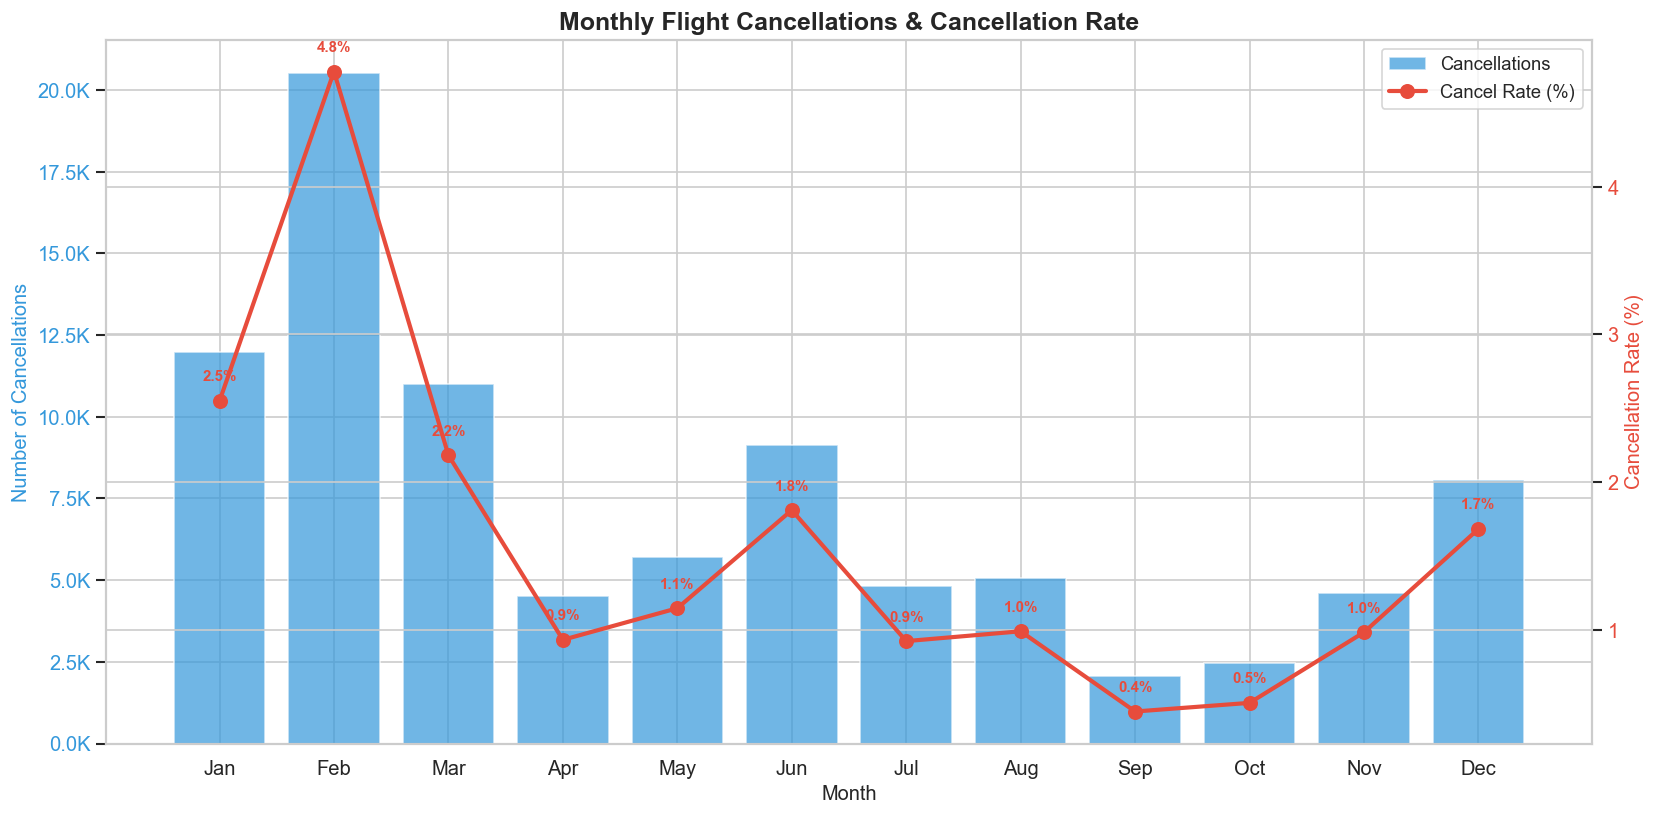

In [9]:
# ── Monthly Cancellation Trends ──────────────────────────────────────
monthly_cancel = df.groupby('MONTH').agg(
    TotalFlights=('CANCELLED', 'count'),
    Cancellations=('CANCELLED', 'sum')
).reset_index()
monthly_cancel['CancelRate'] = (monthly_cancel['Cancellations'] / monthly_cancel['TotalFlights']) * 100

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_cancel['MonthName'] = monthly_cancel['MONTH'].map(lambda m: month_labels[m - 1])

fig, ax1 = plt.subplots(figsize=(14, 7))

color_bar = '#3498db'
color_line = '#e74c3c'

bars = ax1.bar(monthly_cancel['MonthName'], monthly_cancel['Cancellations'],
               color=color_bar, alpha=0.7, label='Cancellations', zorder=2)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Number of Cancellations', color=color_bar, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))

ax2 = ax1.twinx()
ax2.plot(monthly_cancel['MonthName'], monthly_cancel['CancelRate'],
         color=color_line, marker='o', linewidth=2.5, markersize=8,
         label='Cancel Rate (%)', zorder=3)
ax2.set_ylabel('Cancellation Rate (%)', color=color_line, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_line)

# Add rate labels
for i, row in monthly_cancel.iterrows():
    ax2.annotate(f'{row["CancelRate"]:.1f}%',
                 (row['MonthName'], row['CancelRate']),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=9, color=color_line, fontweight='bold')

ax1.set_title('Monthly Flight Cancellations & Cancellation Rate', fontsize=15, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

### 7. Cancellation Types Breakdown

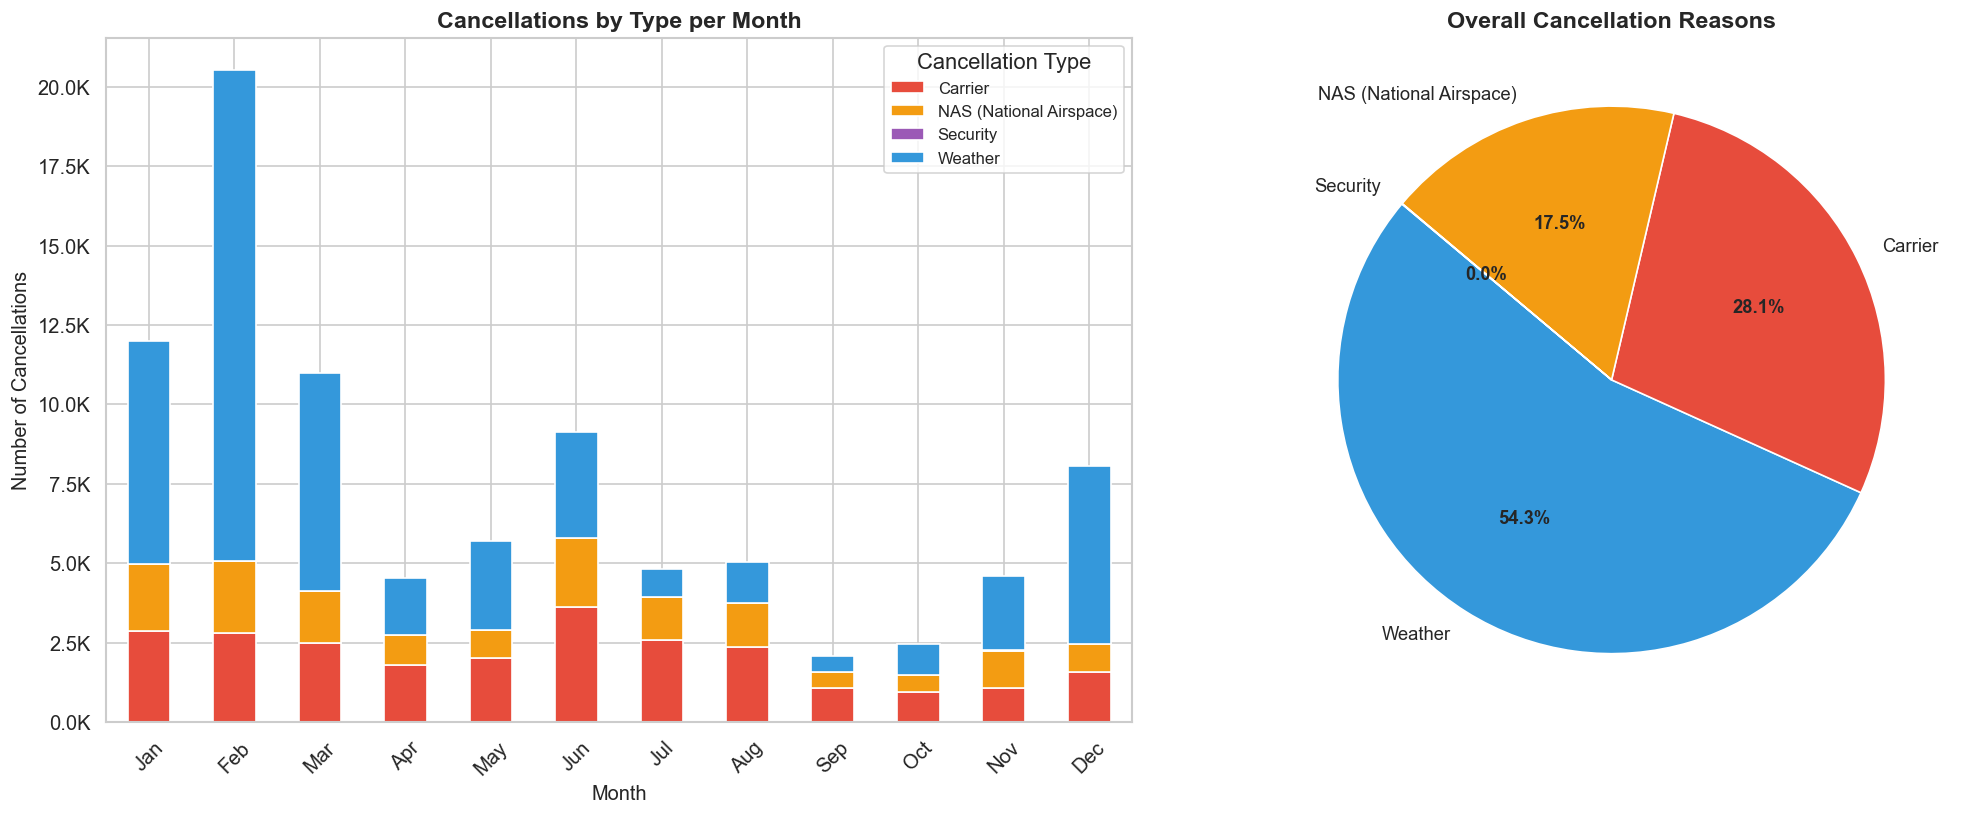


Cancellation Breakdown:
Reason
Weather                    48851
Carrier                    25262
NAS (National Airspace)    15749
Security                      22


In [10]:
# ── Cancellation Types: Carrier (A), Weather (B), NAS (C), Security (D) ──
cancelled_df = df[df['CANCELLED'] == 1].copy()

reason_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS (National Airspace)',
    'D': 'Security'
}
cancelled_df['Reason'] = cancelled_df['CANCELLATION_REASON'].map(reason_map).fillna('Unknown')

# Monthly breakdown
cancel_by_month_type = cancelled_df.groupby(['MONTH', 'Reason']).size().unstack(fill_value=0)
cancel_by_month_type.index = [month_labels[m - 1] for m in cancel_by_month_type.index]

# Stacked bar chart
type_colors = {'Carrier': '#e74c3c', 'Weather': '#3498db',
               'NAS (National Airspace)': '#f39c12', 'Security': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Stacked bar by month
cancel_by_month_type.plot(kind='bar', stacked=True, ax=axes[0],
                          color=[type_colors.get(c, '#95a5a6') for c in cancel_by_month_type.columns])
axes[0].set_title('Cancellations by Type per Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Number of Cancellations', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))
axes[0].legend(title='Cancellation Type', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Right: Overall pie chart
overall_reasons = cancelled_df['Reason'].value_counts()
pie_colors = [type_colors.get(r, '#95a5a6') for r in overall_reasons.index]
wedges, texts, autotexts = axes[1].pie(
    overall_reasons, labels=overall_reasons.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=140, textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Overall Cancellation Reasons', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nCancellation Breakdown:')
print(overall_reasons.to_string())

### 8. Holiday / Winter Month Impact

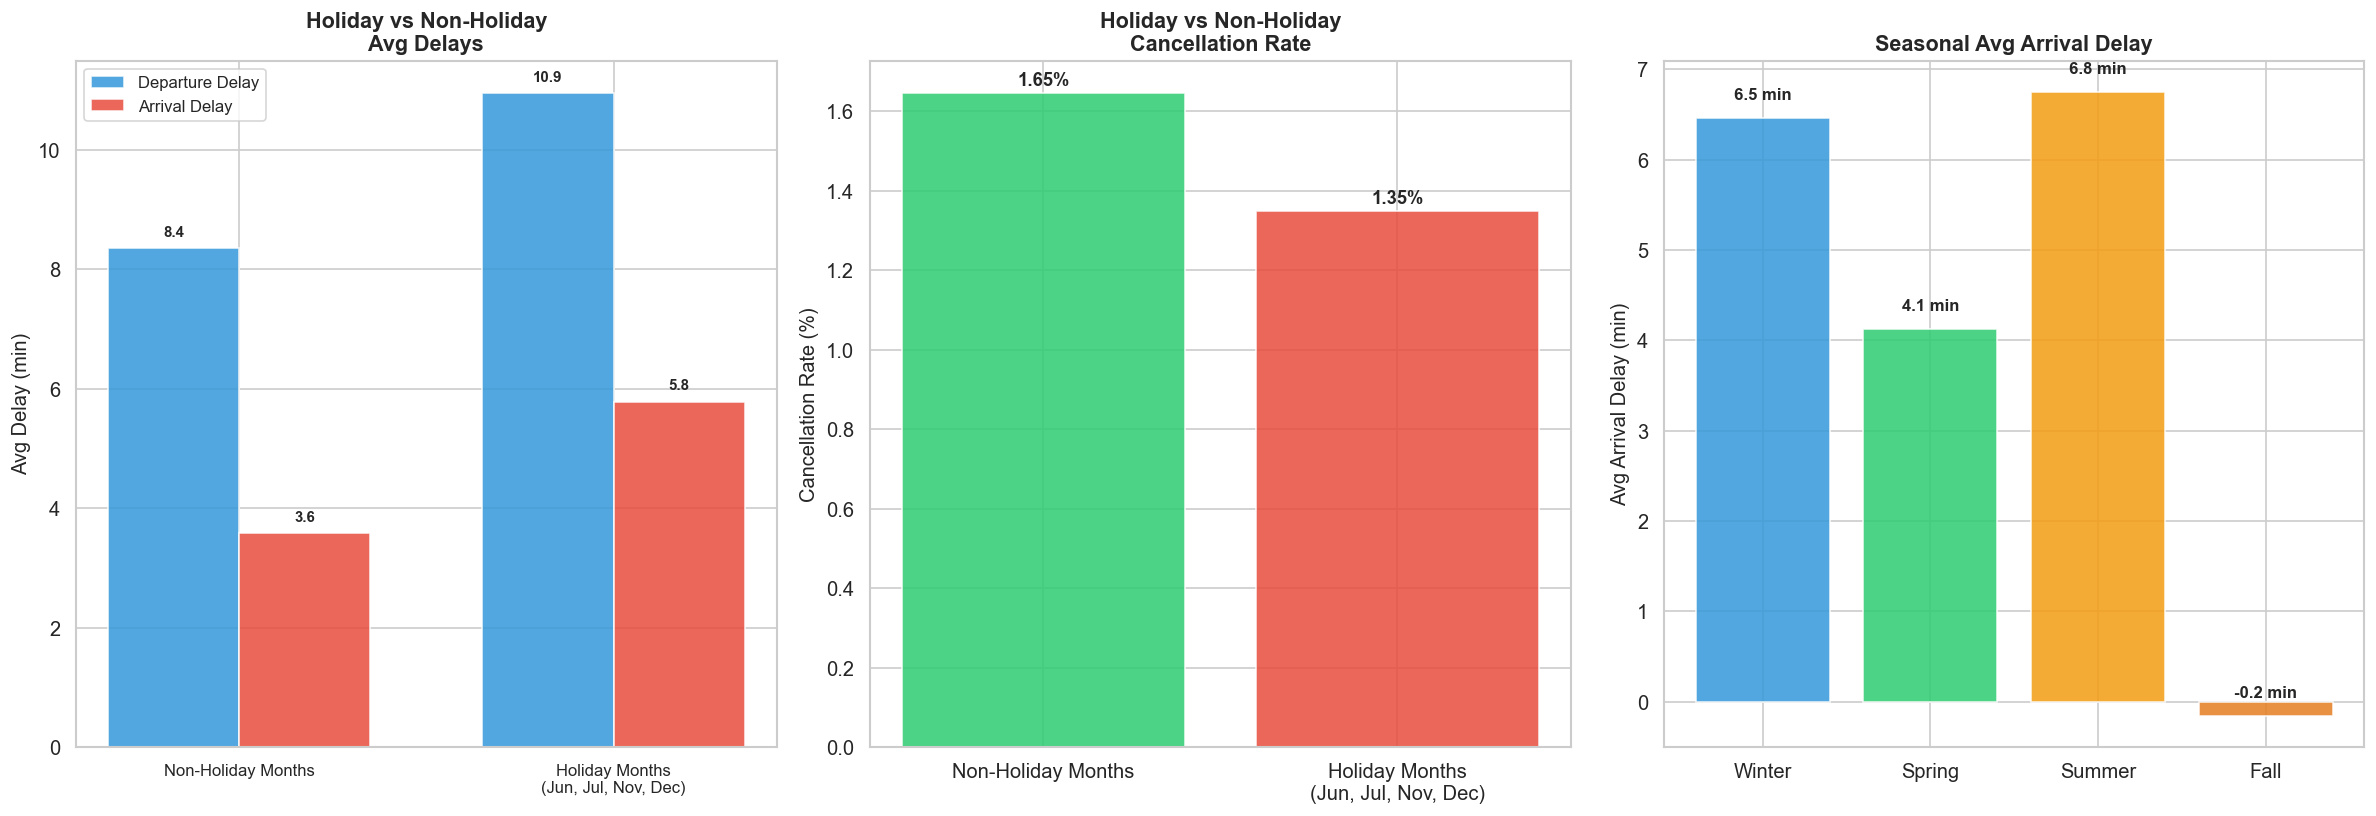


Seasonal Summary:
Season  AvgArrivalDelay  AvgDepartureDelay  CancelRate  TotalFlights
Winter         6.464636          10.803959    2.942711       1378389
Spring         4.126366           8.833737    1.427287       1486456
Summer         6.750105          11.615605    1.236230       1535151
  Fall        -0.158492           5.541392    0.643232       1419083


In [11]:
# ── Holiday / Winter Month Impact Analysis ───────────────────────────
# Define holiday-heavy months: Jun, Jul (summer travel), Nov, Dec (winter holidays)
holiday_months = [6, 7, 11, 12]
winter_months = [1, 2, 12]

df['IsHolidayMonth'] = df['MONTH'].isin(holiday_months)
df['IsWinterMonth'] = df['MONTH'].isin(winter_months)
df['Season'] = df['MONTH'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Compare holiday vs non-holiday
holiday_stats = df.groupby('IsHolidayMonth').agg(
    AvgArrivalDelay=('ARRIVAL_DELAY', 'mean'),
    AvgDepartureDelay=('DEPARTURE_DELAY', 'mean'),
    CancelRate=('CANCELLED', 'mean')
).reset_index()
holiday_stats['CancelRate'] = holiday_stats['CancelRate'] * 100
holiday_stats['Period'] = holiday_stats['IsHolidayMonth'].map({True: 'Holiday Months\n(Jun, Jul, Nov, Dec)', False: 'Non-Holiday Months'})

# Seasonal stats
seasonal_stats = df.groupby('Season').agg(
    AvgArrivalDelay=('ARRIVAL_DELAY', 'mean'),
    AvgDepartureDelay=('DEPARTURE_DELAY', 'mean'),
    CancelRate=('CANCELLED', 'mean'),
    TotalFlights=('CANCELLED', 'count')
).reset_index()
seasonal_stats['CancelRate'] = seasonal_stats['CancelRate'] * 100

# Reorder seasons
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_stats['Season'] = pd.Categorical(seasonal_stats['Season'], categories=season_order, ordered=True)
seasonal_stats = seasonal_stats.sort_values('Season')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Plot 1: Holiday vs Non-Holiday – Avg Delays
x = np.arange(len(holiday_stats))
w = 0.35
bars1 = axes[0].bar(x - w/2, holiday_stats['AvgDepartureDelay'], w,
                     label='Departure Delay', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + w/2, holiday_stats['AvgArrivalDelay'], w,
                     label='Arrival Delay', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(holiday_stats['Period'], fontsize=10)
axes[0].set_ylabel('Avg Delay (min)', fontsize=12)
axes[0].set_title('Holiday vs Non-Holiday\nAvg Delays', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Holiday vs Non-Holiday – Cancel Rate
axes[1].bar(holiday_stats['Period'], holiday_stats['CancelRate'],
            color=['#2ecc71', '#e74c3c'], alpha=0.85)
for i, v in enumerate(holiday_stats['CancelRate']):
    axes[1].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[1].set_title('Holiday vs Non-Holiday\nCancellation Rate', fontsize=13, fontweight='bold')

# Plot 3: Seasonal Comparison
season_colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#f39c12', 'Fall': '#e67e22'}
s_colors = [season_colors[s] for s in seasonal_stats['Season']]

bars3 = axes[2].bar(seasonal_stats['Season'].astype(str), seasonal_stats['AvgArrivalDelay'],
                     color=s_colors, alpha=0.85)
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f} min', ha='center', fontweight='bold', fontsize=10)
axes[2].set_ylabel('Avg Arrival Delay (min)', fontsize=12)
axes[2].set_title('Seasonal Avg Arrival Delay', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nSeasonal Summary:')
print(seasonal_stats[['Season', 'AvgArrivalDelay', 'AvgDepartureDelay', 'CancelRate', 'TotalFlights']].to_string(index=False))

### 9. Seasonal Delay Trends (Monthly)

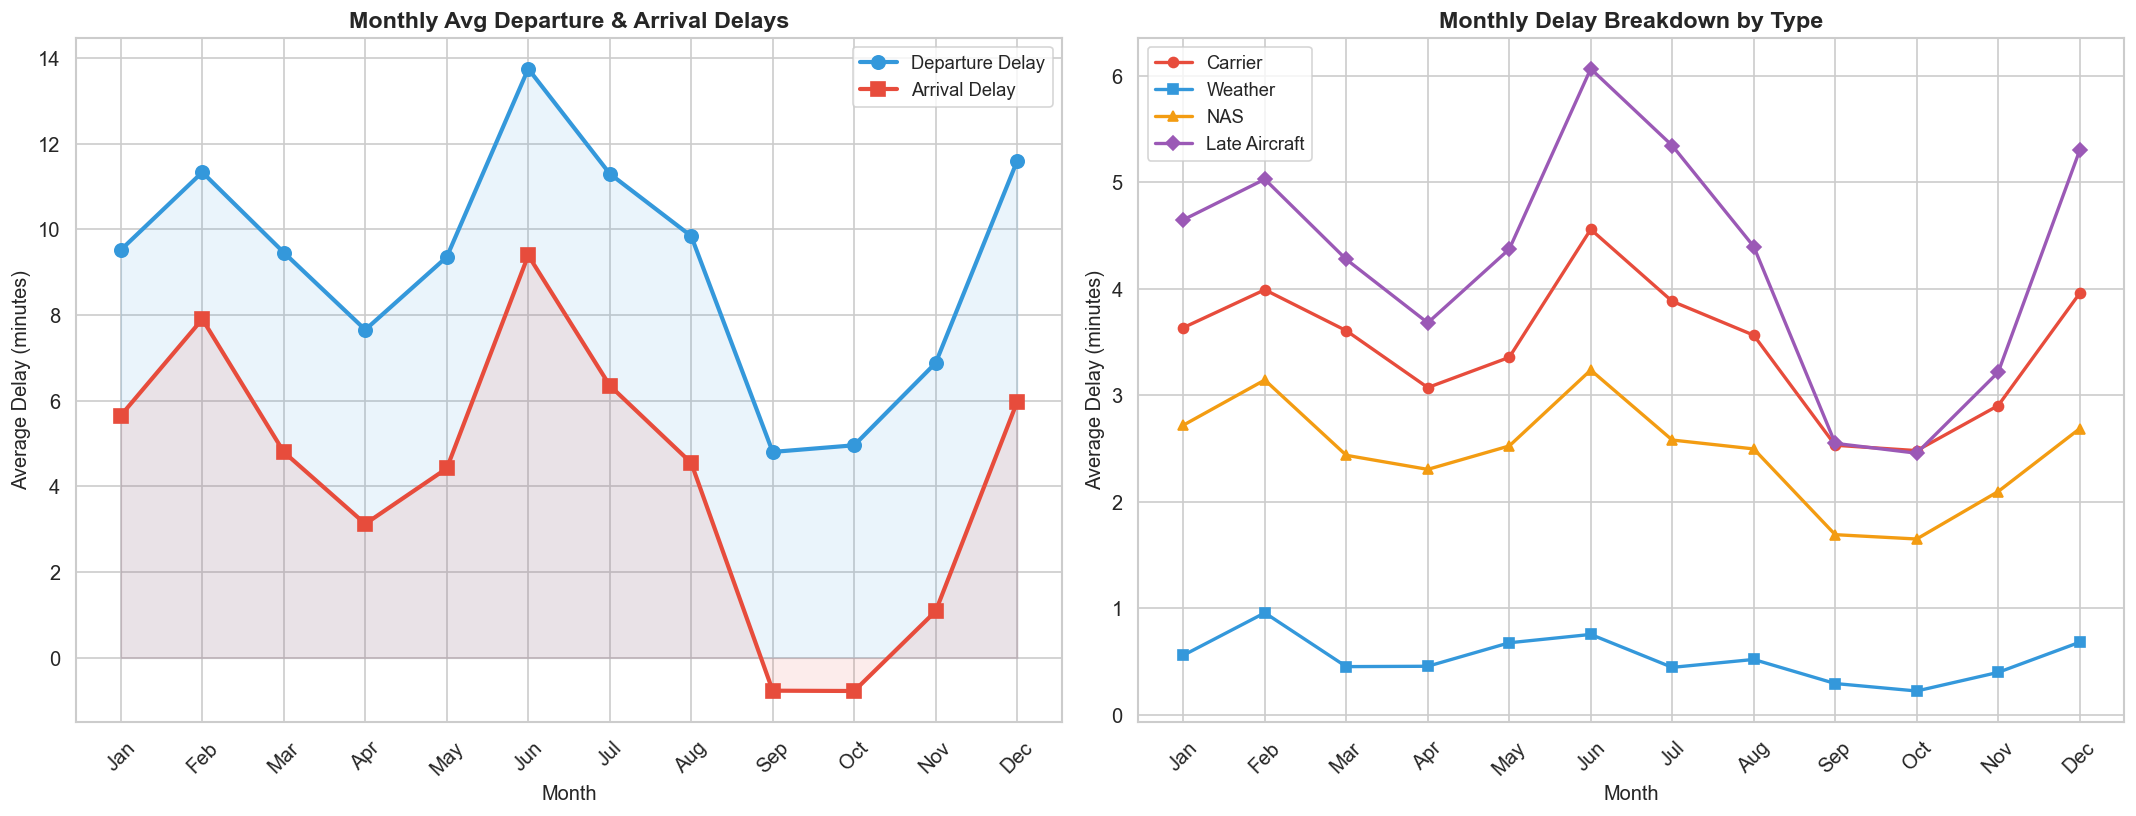

In [12]:
# ── Monthly Average Delay Trend Lines ────────────────────────────────
monthly_delays = df.groupby('MONTH').agg(
    AvgDepDelay=('DEPARTURE_DELAY', 'mean'),
    AvgArrDelay=('ARRIVAL_DELAY', 'mean'),
    AvgCarrier=('AIRLINE_DELAY', 'mean'),
    AvgWeather=('WEATHER_DELAY', 'mean'),
    AvgNAS=('AIR_SYSTEM_DELAY', 'mean'),
    AvgLateAircraft=('LATE_AIRCRAFT_DELAY', 'mean')
).reset_index()
monthly_delays['MonthName'] = monthly_delays['MONTH'].map(lambda m: month_labels[m - 1])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Departure and Arrival delay trends
axes[0].plot(monthly_delays['MonthName'], monthly_delays['AvgDepDelay'],
             marker='o', linewidth=2.5, color='#3498db', label='Departure Delay', markersize=8)
axes[0].plot(monthly_delays['MonthName'], monthly_delays['AvgArrDelay'],
             marker='s', linewidth=2.5, color='#e74c3c', label='Arrival Delay', markersize=8)
axes[0].fill_between(monthly_delays['MonthName'], monthly_delays['AvgDepDelay'],
                      alpha=0.1, color='#3498db')
axes[0].fill_between(monthly_delays['MonthName'], monthly_delays['AvgArrDelay'],
                      alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Average Delay (minutes)', fontsize=12)
axes[0].set_title('Monthly Avg Departure & Arrival Delays', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Right: Delay type breakdown by month
axes[1].plot(monthly_delays['MonthName'], monthly_delays['AvgCarrier'],
             marker='o', linewidth=2, label='Carrier', color='#e74c3c')
axes[1].plot(monthly_delays['MonthName'], monthly_delays['AvgWeather'],
             marker='s', linewidth=2, label='Weather', color='#3498db')
axes[1].plot(monthly_delays['MonthName'], monthly_delays['AvgNAS'],
             marker='^', linewidth=2, label='NAS', color='#f39c12')
axes[1].plot(monthly_delays['MonthName'], monthly_delays['AvgLateAircraft'],
             marker='D', linewidth=2, label='Late Aircraft', color='#9b59b6')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Average Delay (minutes)', fontsize=12)
axes[1].set_title('Monthly Delay Breakdown by Type', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 10. Route Congestion Insights

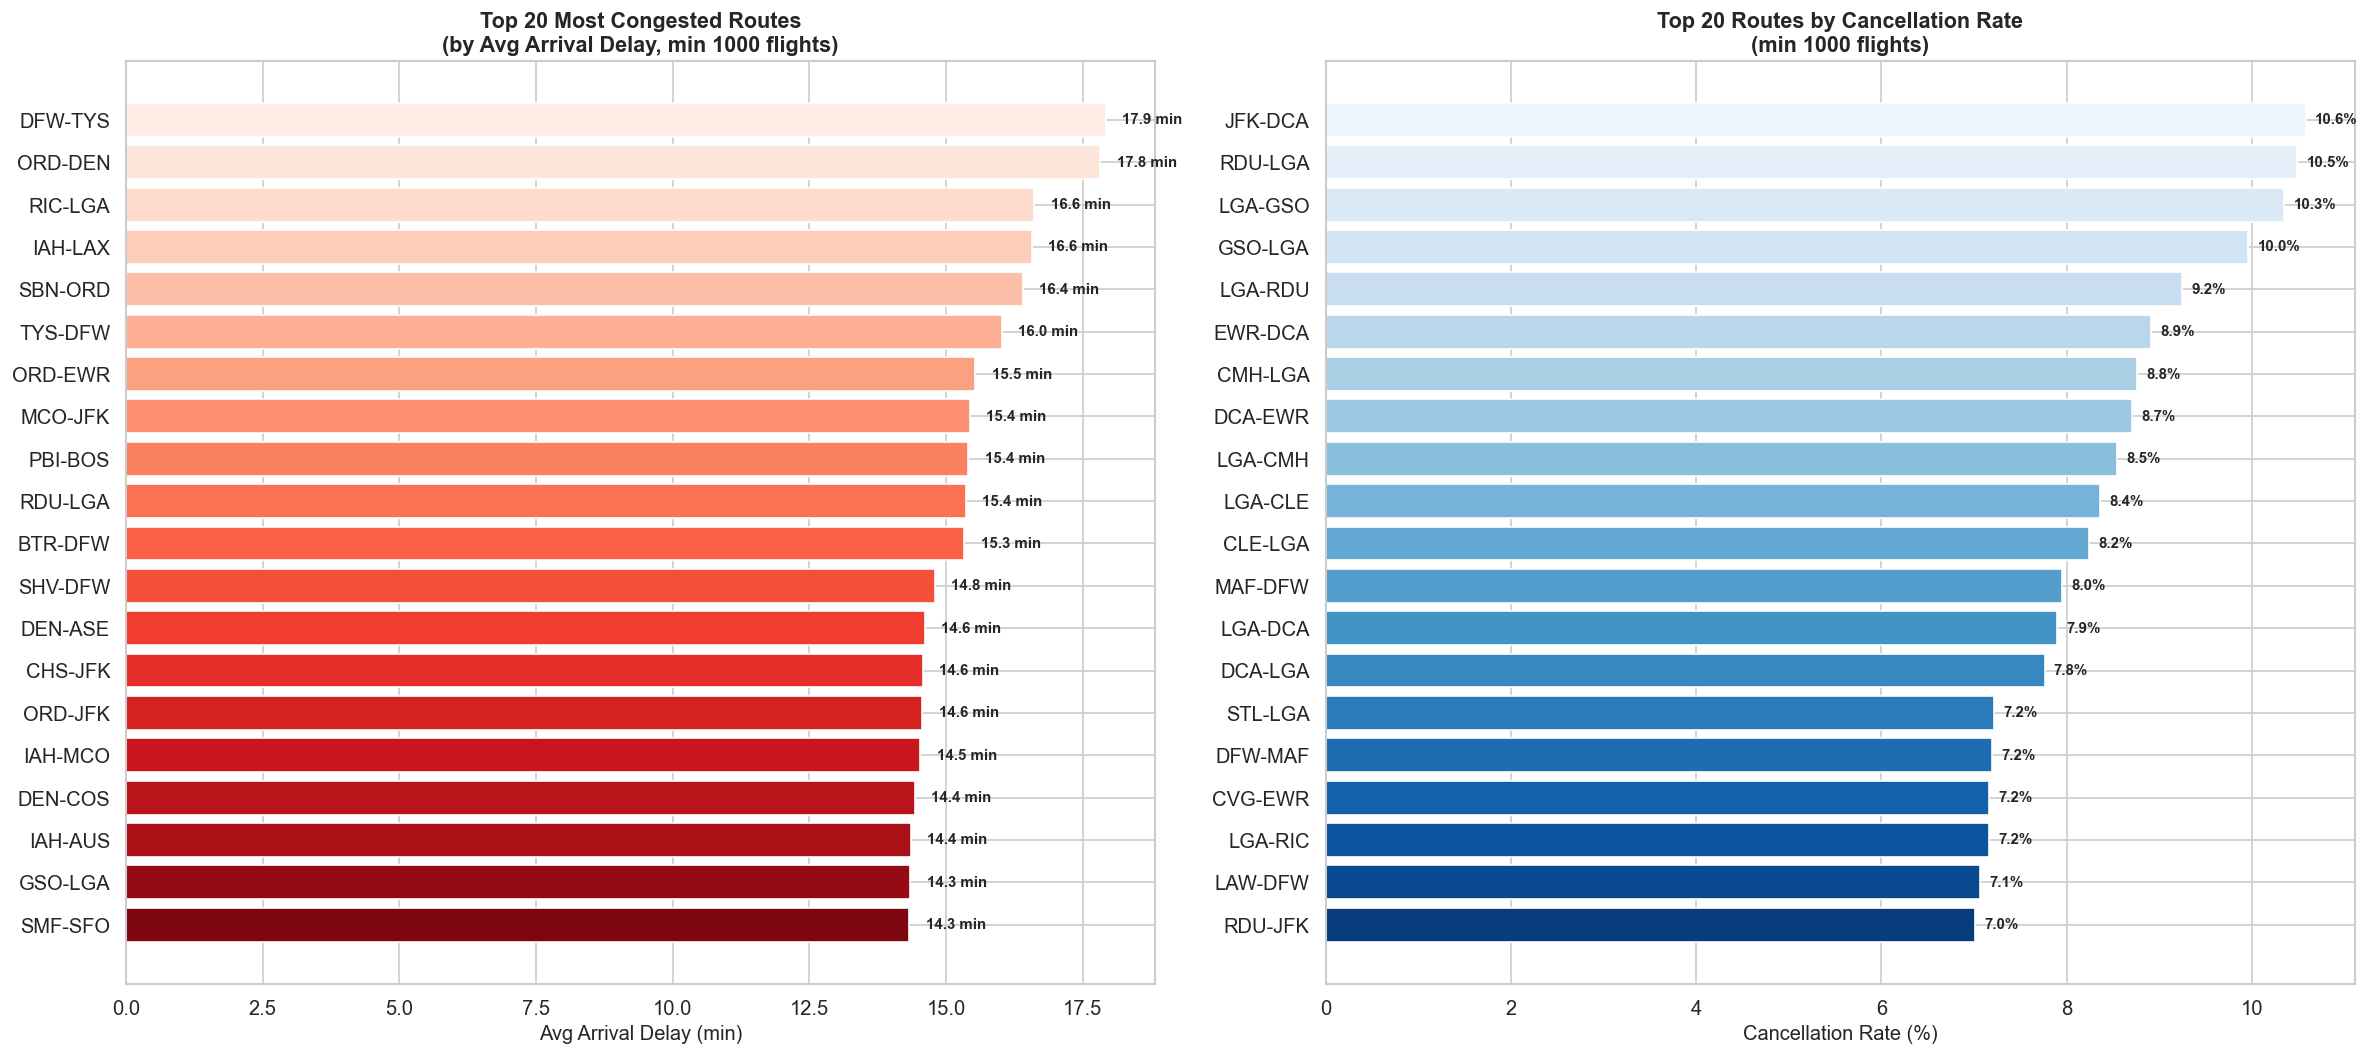


── Top 10 Most Congested Routes ──
  ROUTE  TotalFlights  AvgArrDelay  CancelRate
DFW-TYS          1626    17.928043    2.952030
ORD-DEN          5613    17.825405    1.354000
RIC-LGA          1381    16.616943    6.806662
IAH-LAX          4432    16.572203    0.879964
SBN-ORD          1144    16.399475    5.069930
TYS-DFW          1624    16.019705    3.078818
ORD-EWR          3874    15.537170    2.916882
MCO-JFK          5346    15.432286    1.608679
PBI-BOS          1606    15.408468    2.054795
RDU-LGA          1878    15.362087   10.489883

── Top 10 Routes by Cancellation Rate ──
  ROUTE  TotalFlights  Cancellations  CancelRate
JFK-DCA          1002            106   10.578842
RDU-LGA          1878            197   10.489883
LGA-GSO          1295            134   10.347490
GSO-LGA          1295            129    9.961390
LGA-RDU          1957            181    9.248850
EWR-DCA          1515            135    8.910891
CMH-LGA          1439            126    8.756081
DCA-EWR      

In [13]:
# ── Route Congestion & Cancellation Analysis ─────────────────────────
route_stats = df.groupby('ROUTE').agg(
    TotalFlights=('CANCELLED', 'count'),
    Cancellations=('CANCELLED', 'sum'),
    AvgArrDelay=('ARRIVAL_DELAY', 'mean'),
    AvgDepDelay=('DEPARTURE_DELAY', 'mean'),
    AvgDistance=('DISTANCE', 'mean')
).reset_index()
route_stats['CancelRate'] = (route_stats['Cancellations'] / route_stats['TotalFlights']) * 100

# Top 20 most congested routes (highest avg delay among busy routes)
busy_routes = route_stats[route_stats['TotalFlights'] >= 1000].copy()
top_congested = busy_routes.nlargest(20, 'AvgArrDelay')
top_cancel_routes = busy_routes.nlargest(20, 'CancelRate')

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Left: Most Congested Routes (by delay)
colors_delay = sns.color_palette('Reds_r', n_colors=20)
axes[0].barh(top_congested['ROUTE'][::-1], top_congested['AvgArrDelay'][::-1], color=colors_delay)
for i, (_, row) in enumerate(top_congested[::-1].iterrows()):
    axes[0].text(row['AvgArrDelay'] + 0.3, i, f'{row["AvgArrDelay"]:.1f} min',
                 va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Avg Arrival Delay (min)', fontsize=12)
axes[0].set_title('Top 20 Most Congested Routes\n(by Avg Arrival Delay, min 1000 flights)',
                   fontsize=13, fontweight='bold')

# Right: Highest Cancellation Rate Routes
colors_cancel = sns.color_palette('Blues_r', n_colors=20)
axes[1].barh(top_cancel_routes['ROUTE'][::-1], top_cancel_routes['CancelRate'][::-1], color=colors_cancel)
for i, (_, row) in enumerate(top_cancel_routes[::-1].iterrows()):
    axes[1].text(row['CancelRate'] + 0.1, i, f'{row["CancelRate"]:.1f}%',
                 va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)', fontsize=12)
axes[1].set_title('Top 20 Routes by Cancellation Rate\n(min 1000 flights)',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n── Top 10 Most Congested Routes ──')
print(top_congested[['ROUTE', 'TotalFlights', 'AvgArrDelay', 'CancelRate']].head(10).to_string(index=False))
print('\n── Top 10 Routes by Cancellation Rate ──')
print(top_cancel_routes[['ROUTE', 'TotalFlights', 'Cancellations', 'CancelRate']].head(10).to_string(index=False))

---
## Key Insights & Summary

### Route & Airport Findings
- Identified the top 10 busiest origin–destination pairs and the airports driving the most traffic.
- Delay heatmaps reveal which airports and routes suffer most from specific delay categories (Carrier, Weather, NAS, Late Aircraft).
- Interactive Folium maps provide a geographic view of flight volume concentration and delay severity.

### Cancellation & Seasonal Findings
- Monthly cancellation trends show peak cancellations correlating with winter weather months.
- Weather (B) and Carrier (A) are the dominant cancellation reasons, while Security (D) cancellations are extremely rare.
- Holiday months (Jun, Jul, Nov, Dec) exhibit distinct delay and cancellation patterns compared to non-holiday periods.
- The seasonal delay breakdown shows how different delay types (Carrier, Weather, NAS, Late Aircraft) fluctuate month-to-month.

### Route Congestion & Cancellation Deliverables
- Top congested routes identified based on average arrival delay (≥1000 flights).